<div style="text-align:center; padding:20px 0">
<img src="https://raw.githubusercontent.com/dataprojectlabs/DataProjectLab-projects/refs/heads/main/media/banners/banner_logitrack_nb2_solution.png" width="100%"/>
</div>



> **Comment lire ce corrigé :**  
> Les blocs `MÉTHODE` expliquent les choix techniques et les patterns généralisables.  
> Les blocs `INTERPRÉTATION` lisent les résultats.  
> Les blocs `MÉTIER` font le lien entre le chiffre et la décision business.

| | |
|---|---|
| **Prérequis** | Notebook 1 complété |


> Le Notebook 1 a identifié **9 anomalies** et établi les KPIs de référence. Ce notebook les corrige toutes systématiquement, construit les variables analytiques clés et exporte la table finale `logitrack_analytics.csv`.

---
## 0. Mise en place de l'environnement

In [3]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os, sys

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)

COLORS = {
    'primary':   '#534AB7',
    'secondary': '#1D9E75',
    'warning':   '#EF9F27',
    'danger':    '#E24B4A',
    'neutral':   '#888780',
    'light':     '#EEEDFE',
}
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#F9F9F8',
    'axes.grid':        True,
    'grid.alpha':       0.35,
    'font.size':        11,
})

IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    SAVE_PATH = '/content/drive/MyDrive/DataProjectLab/projects/logitrack/'
else:
    SAVE_PATH = './outputs/'
os.makedirs(SAVE_PATH, exist_ok=True)
print(f'📁 Environnement : {"Colab" if IN_COLAB else "Local"}')
print(f'📁 Dossier       : {SAVE_PATH}')
print('Configuration chargée ✅')

📁 Environnement : Local
📁 Dossier       : ./outputs/
Configuration chargée ✅


---
## Étape 1 — Chargement depuis zéro

### MÉTHODE
On recharge les 7 CSV depuis zéro — état propre et reproductible. Ne jamais continuer depuis l'état du Notebook 1 sans recharger : les opérations interactives d'exploration peuvent avoir modifié des DataFrames en mémoire.

In [4]:
BASE_URL = 'https://raw.githubusercontent.com/dataprojectlabs/DataProjectLab-projects/refs/heads/main/projets/logitrack_analytics/data/'

df_liv  = pd.read_csv(BASE_URL + 'livraisons.csv',
                       parse_dates=['date_creation','date_enlevement',
                                    'date_livraison_prevue','date_livraison_reelle'])
df_trp  = pd.read_csv(BASE_URL + 'transporteurs.csv')
df_ent  = pd.read_csv(BASE_URL + 'entrepots.csv')
df_rte  = pd.read_csv(BASE_URL + 'routes.csv')
df_cli  = pd.read_csv(BASE_URL + 'clients.csv')
df_evt  = pd.read_csv(BASE_URL + 'evenements.csv',  parse_dates=['date_evenement'])
df_alt  = pd.read_csv(BASE_URL + 'alertes_sla.csv', parse_dates=['date_alerte'])

print('Chargement OK ✅')
for name, df in [('livraisons',df_liv),('transporteurs',df_trp),('entrepots',df_ent),
                  ('routes',df_rte),('clients',df_cli),('evenements',df_evt),
                  ('alertes_sla',df_alt)]:
    print(f'  {name:<20} {len(df):>7,} lignes x {len(df.columns)} colonnes')

Chargement OK ✅
  livraisons            15,000 lignes x 32 colonnes
  transporteurs             15 lignes x 9 colonnes
  entrepots                 12 lignes x 7 colonnes
  routes                    30 lignes x 8 colonnes
  clients                   30 lignes x 8 colonnes
  evenements            28,286 lignes x 7 colonnes
  alertes_sla            4,972 lignes x 10 colonnes


---
## Étape 2 — Nettoyage des anomalies

### MÉTHODE — Ordre de correction
On suit toujours le même ordre :
1. **Doublons** (réduire le volume avant les autres opérations)
2. **Aberrants numériques** (poids négatifs, CSAT hors plage)
3. **Incohérences calculées** (délais aberrants)
4. **Exclusions métier** (transporteur suspendu)

**Règle fondamentale :** on ne supprime jamais de la table source. On applique des filtres et corrections dans `df_liv` tout en conservant les lignes brutes dans `df_liv_raw` pour traçabilité.

In [5]:
# Sauvegarde de la table brute pour traçabilité
df_liv_raw = df_liv.copy()
print(f'Table brute sauvegardée : {len(df_liv_raw):,} lignes')

Table brute sauvegardée : 15,000 lignes


### 2.1 — Doublons sur livraison_id

In [6]:
n_avant = len(df_liv)
df_liv = df_liv.drop_duplicates(subset=['livraison_id'], keep='first')
print(f'Doublons supprimés : {n_avant - len(df_liv)} (avant={n_avant:,}, après={len(df_liv):,})')

Doublons supprimés : 0 (avant=15,000, après=15,000)


### 2.2 — Poids kg aberrants (≤ 0)

> **MÉTHODE — Imputation par médiane du type_colis**
>
> On impute par la médiane du même `type_colis` plutôt que la médiane globale. Un colis Pharmaceutique et un colis Industriel n'ont pas les mêmes distributions de poids — une médiane globale introduirait un biais.

In [ ]:
mask_poids = df_liv['poids_kg'] <= 0
print(f'Poids aberrants détectés : {mask_poids.sum()}')
print(df_liv[mask_poids][['livraison_id','type_colis','poids_kg']])

# Imputation par médiane du type_colis
medianes_poids = df_liv[df_liv['poids_kg'] > 0].groupby('type_colis')['poids_kg'].median()
for idx in df_liv[mask_poids].index:
    tc = df_liv.loc[idx, 'type_colis']
    df_liv.loc[idx, 'poids_kg'] = medianes_poids.get(tc, df_liv['poids_kg'].median()) 

print(f'\nPoids après correction :')
print(df_liv.loc[mask_poids[mask_poids].index, ['livraison_id','type_colis','poids_kg']])

Poids aberrants détectés : 2
     livraison_id type_colis  poids_kg
549     LIV000550  Documents     -5.00
9099    LIV009100  Documents     -5.00

Poids après correction :
     livraison_id type_colis  poids_kg
549     LIV000550  Documents     56.05
9099    LIV009100  Documents     56.05


> **INTERPRÉTATION :**  **2 poids aberrants** (LIV000550 et LIV009100) corrigés par la médiane de leur `type_colis`. La médiane est préférée à la moyenne car elle est robuste aux valeurs extrêmes — les colis très lourds (>1000 kg) tireraient la moyenne vers le haut.

### 2.3 — CSAT hors plage [1-5]

In [8]:
mask_csat = df_liv['csat'].notna() & ((df_liv['csat'] < 1) | (df_liv['csat'] > 5))
print(f'CSAT hors plage : {mask_csat.sum()}')
print(df_liv[mask_csat][['livraison_id','csat','statut']])

# Remplacement par NULL — valeur inconnue vaut mieux qu'une valeur fausse
df_liv.loc[mask_csat, 'csat'] = np.nan
print(f'\nCSAT remplacé par NULL pour {mask_csat.sum()} lignes')
print(f'Total CSAT renseigné : {df_liv["csat"].notna().sum():,}')

CSAT hors plage : 2
     livraison_id  csat             statut
303     LIV000304  0.00  Livré avec retard
1204    LIV001205  6.20              Livré

CSAT remplacé par NULL pour 2 lignes
Total CSAT renseigné : 9,559


> **INTERPRÉTATION :** **CSAT hors plage** remplacés par `NULL`. On préfère l'absence de valeur à une valeur erronée — un CSAT de 6.2 n'a pas de sens sur une échelle 1-5 et biaiserait le calcul de la moyenne.
>
> **MÉTIER :** Ces erreurs proviennent probablement d'une interface de saisie sans validation côté application. Recommandation : ajouter une contrainte `CHECK (csat BETWEEN 1 AND 5)` dans la base source.

### 2.4 — Délais aberrants (-99j)

> **MÉTHODE — Recalcul depuis les dates sources**
>
> `delai_jours = duree_reelle_jours - sla_jours_contractuel` est une colonne calculée. Quand elle est aberrante, on la recalcule depuis ses composantes — qui, elles, sont fiables. C'est le principe de **dériver le calculé depuis le primitif**.

In [9]:
mask_delai = df_liv['delai_jours'] < -30
print(f'Délais aberrants (< -30j) : {mask_delai.sum()}')
print(df_liv[mask_delai][['livraison_id','delai_jours','duree_reelle_jours','sla_jours_contractuel']])

# Recalcul depuis les colonnes sources
df_liv.loc[mask_delai, 'delai_jours'] = (
    df_liv.loc[mask_delai, 'duree_reelle_jours']
    - df_liv.loc[mask_delai, 'sla_jours_contractuel']
).round(1)

print(f'\nDélais après correction :')
print(df_liv.loc[mask_delai[mask_delai].index, ['livraison_id','delai_jours','duree_reelle_jours','sla_jours_contractuel']])

Délais aberrants (< -30j) : 4
     livraison_id  delai_jours  duree_reelle_jours  sla_jours_contractuel
141     LIV000142       -99.00               14.50                     13
890     LIV000891       -99.00                2.10                     14
2340    LIV002341       -99.00               21.40                      5
7822    LIV007823       -99.00               13.00                     14

Délais après correction :
     livraison_id  delai_jours  duree_reelle_jours  sla_jours_contractuel
141     LIV000142         1.50               14.50                     13
890     LIV000891       -11.90                2.10                     14
2340    LIV002341        16.40               21.40                      5
7822    LIV007823        -1.00               13.00                     14


> **INTERPRÉTATION :** **4 délais aberrants** (-99j) corrigés par recalcul. Les colonnes `duree_reelle_jours` et `sla_jours_contractuel` sont intactes — seule la colonne calculée `delai_jours` était corrompue.

### 2.5 — Exclusion du transporteur suspendu

In [ ]:
trp_actifs = df_trp[df_trp['actif'] == True]['transporteur_id'].tolist()
n_avant = len(df_liv)
mask_suspendu = ~df_liv['transporteur_id'].isin(trp_actifs)
print(f'Livraisons avec transporteur suspendu : {mask_suspendu.sum()}')
print(df_liv[mask_suspendu]['transporteur_id'].value_counts())

# On garde ces livraisons dans df_liv mais on les marquera dans les analyses
df_liv['transporteur_actif'] = df_liv['transporteur_id'].isin(trp_actifs).astype(int)
print(f'\nColonne transporteur_actif créée :')
print(df_liv['transporteur_actif'].value_counts())b

Livraisons avec transporteur suspendu : 0
Series([], Name: count, dtype: int64)

Colonne transporteur_actif créée :
transporteur_actif
1    15000
Name: count, dtype: int64


> **INTERPRÉTATION :** Les livraisons de TRP15 ne sont pas supprimées — elles représentent des opérations réelles passées. On crée une colonne `transporteur_actif` (0/1) pour les filtrer à la demande dans les analyses et exclure TRP15 des benchmarks de performance.
>
> **MÉTIER :** Conserver ces lignes est important pour l'analyse du coût du turnover transporteur — savoir combien a coûté l'utilisation d'un partenaire peu fiable avant sa suspension.

In [11]:
print('=== BILAN NETTOYAGE ===')
print(f'  Lignes brutes         : {len(df_liv_raw):,}')
print(f'  Lignes après nettoyage : {len(df_liv):,}')
print(f'  Poids corrigés         : 2')
print(f'  CSAT mis à NULL        : 3')
print(f'  Délais recalculés      : 4')
print(f'  Transporteur suspendu  : marqué (colonne transporteur_actif)')
print(f'  Nulls restants delai_jours : {df_liv["delai_jours"].isna().sum()}')
print(f'  CSAT non renseigné     : {df_liv["csat"].isna().sum():,} ({df_liv["csat"].isna().mean()*100:.1f}%)')

=== BILAN NETTOYAGE ===
  Lignes brutes         : 15,000
  Lignes après nettoyage : 15,000
  Poids corrigés         : 2
  CSAT mis à NULL        : 3
  Délais recalculés      : 4
  Transporteur suspendu  : marqué (colonne transporteur_actif)
  Nulls restants delai_jours : 0
  CSAT non renseigné     : 5,441 (36.3%)


---
## Étape 3 — Feature Engineering

### MÉTHODE — Pourquoi créer des features ?
Le modèle ML de NB5 ne peut pas utiliser les colonnes brutes directement :
- `transporteur_id` est un identifiant — le modèle ne peut pas apprendre de `TRP12` sans contexte de performance
- `pays_origine` est une chaîne — il faut l'encoder ou extraire sa sémantique (risque douanier)
- `date_creation` est une date — il faut en extraire les composantes temporelles

**Objectif :** créer des features que le modèle peut interpréter et qui capturent la connaissance métier.

### 3.1 — Variables temporelles

> **MÉTHODE — Pourquoi le mois en sin/cos ?**
>
> Le mois est cyclique : décembre (12) est proche de janvier (1) dans la réalité, mais `12 - 1 = 11` numériquement. Encoder en `sin(2π × mois/12)` et `cos(2π × mois/12)` préserve cette proximité cyclique — le modèle comprendra que décembre et janvier sont dans le même pic saisonnier.

In [12]:
# Variables temporelles de base (déjà dans le CSV, on valide)
print('Variables temporelles existantes :')
print(df_liv[['mois','annee','jour_semaine','est_weekend']].describe())

# Encodage cyclique du mois
df_liv['mois_sin'] = np.sin(2 * np.pi * df_liv['mois'] / 12)
df_liv['mois_cos'] = np.cos(2 * np.pi * df_liv['mois'] / 12)

# Heure d'enlèvement
df_liv['heure_enlevement'] = df_liv['date_enlevement'].dt.hour

# Fin de mois (J-3 à J0) — les expéditions fin de mois sont souvent plus risquées
df_liv['est_fin_mois'] = (df_liv['date_creation'].dt.day >= 28).astype(int)

# Délai entre création et enlèvement (temps de préparation)
df_liv['delai_prep_heures'] = (
    df_liv['date_enlevement'] - df_liv['date_creation']
).dt.total_seconds() / 3600
df_liv['delai_prep_heures'] = df_liv['delai_prep_heures'].clip(lower=0).round(1)

print(f'\nVariables temporelles créées :')
print(f'  mois_sin / mois_cos : encodage cyclique')
print(f'  heure_enlevement    : min={df_liv["heure_enlevement"].min()}, max={df_liv["heure_enlevement"].max()}')
print(f'  est_fin_mois        : {df_liv["est_fin_mois"].mean()*100:.1f}% des livraisons')
print(f'  delai_prep_heures   : mean={df_liv["delai_prep_heures"].mean():.1f}h, max={df_liv["delai_prep_heures"].max():.0f}h')

Variables temporelles existantes :
          mois    annee  jour_semaine  est_weekend
count 15000.00 15000.00      15000.00     15000.00
mean      6.67  2022.51          3.03         0.29
std       3.63     0.50          1.99         0.45
min       1.00  2022.00          0.00         0.00
25%       3.00  2022.00          1.00         0.00
50%       7.00  2023.00          3.00         0.00
75%      10.00  2023.00          5.00         1.00
max      12.00  2023.00          6.00         1.00

Variables temporelles créées :
  mois_sin / mois_cos : encodage cyclique
  heure_enlevement    : min=0, max=0
  est_fin_mois        : 11.5% des livraisons
  delai_prep_heures   : mean=1.0h, max=24h


> **INTERPRÉTATION :**
> - **11.5%** des livraisons sont créées en fin de mois — pics de fin de période contractuelle
> - Le délai de préparation moyen (~1h) capte l'efficacité logistique à l'origine
>
> **MÉTIER :** Un délai de préparation > 48h avant enlèvement est souvent le premier signe d'un problème opérationnel. Le modèle ML pourra apprendre que `delai_prep_heures > 48` est un signal de risque.

### 3.2 — Features de performance historique

### MÉTHODE — Anti-leakage sur les taux historiques
> Le taux de breach d'un transporteur calculé sur **toutes** les données serait du leakage : le modèle connaîtrait déjà les performances futures. On calcule les taux sur les données **passées uniquement** — pour chaque livraison, on n'utilise que les livraisons antérieures.
>
> En NB5, la coupure temporelle gérera ce problème proprement. Ici, pour la simplicité, on calcule les taux sur l'ensemble et on note qu'en production le calcul sera fenêtré.

In [13]:
# Taux breach historique par transporteur
taux_breach_trp = (
    df_liv.groupby('transporteur_id')['sla_breach']
    .mean()
    .reset_index()
    .rename(columns={'sla_breach': 'taux_breach_transporteur'})
)
df_liv = df_liv.merge(taux_breach_trp, on='transporteur_id', how='left')

# Taux breach historique par corridor (pays_origine + pays_destination)
taux_breach_corr = (
    df_liv.groupby(['pays_origine','pays_destination'])['sla_breach']
    .mean()
    .reset_index()
    .rename(columns={'sla_breach': 'taux_breach_corridor'})
)
df_liv = df_liv.merge(taux_breach_corr, on=['pays_origine','pays_destination'], how='left')

# Taux breach par entrepôt d'origine
taux_breach_ent = (
    df_liv.groupby('entrepot_origine_id')['sla_breach']
    .mean()
    .reset_index()
    .rename(columns={'sla_breach': 'taux_breach_entrepot_origine'})
)
df_liv = df_liv.merge(taux_breach_ent, on='entrepot_origine_id', how='left')

print('Features de performance historique créées :')
print(f'  taux_breach_transporteur    : mean={df_liv["taux_breach_transporteur"].mean():.3f}')
print(f'  taux_breach_corridor        : mean={df_liv["taux_breach_corridor"].mean():.3f}')
print(f'  taux_breach_entrepot_origine: mean={df_liv["taux_breach_entrepot_origine"].mean():.3f}')

Features de performance historique créées :
  taux_breach_transporteur    : mean=0.390
  taux_breach_corridor        : mean=0.390
  taux_breach_entrepot_origine: mean=0.390


### 3.3 — Features logistiques métier

In [14]:
# Enrichissement depuis routes
df_liv = df_liv.merge(
    df_rte[['route_id','distance_km','duree_standard_jours',
            'risque_douanier','nb_points_controle']],
    on='route_id', how='left'
)

# Ratio durée réelle vs durée standard (> 1 = plus lent que prévu)
df_liv['ratio_duree_vs_standard'] = (
    df_liv['duree_reelle_jours'] / df_liv['duree_standard_jours']
).round(3)

# Délai relatif SLA — à quel % du SLA la livraison a été effectuée
# 0.8 = livré à 80% du délai disponible | 1.2 = 20% au-delà du SLA
df_liv['delai_relatif_sla'] = (
    df_liv['duree_reelle_jours'] / df_liv['sla_jours_contractuel']
).round(3)

# Encodage numérique du risque douanier
risque_map = {'Faible': 0, 'Moyen': 1, 'Élevé': 2}
df_liv['risque_douanier_num'] = df_liv['risque_douanier'].map(risque_map)

# Encodage de la priorité
priorite_map = {'Standard': 0, 'Express': 1, 'Urgent': 2}
df_liv['priorite_num'] = df_liv['priorite'].map(priorite_map)

# Densité du colis (poids / volume) — indicateur de type de marchandise
df_liv['densite_kg_m3'] = (df_liv['poids_kg'] / df_liv['volume_m3'].replace(0, np.nan)).round(1)

print('Features logistiques créées :')
print(f'  ratio_duree_vs_standard : mean={df_liv["ratio_duree_vs_standard"].mean():.2f}')
print(f'  delai_relatif_sla       : mean={df_liv["delai_relatif_sla"].mean():.2f} (>1 = breach)')
print(f'  risque_douanier_num     : {df_liv["risque_douanier_num"].value_counts().to_dict()}')
print(f'  priorite_num            : {df_liv["priorite_num"].value_counts().to_dict()}')

Features logistiques créées :
  ratio_duree_vs_standard : mean=1.74
  delai_relatif_sla       : mean=1.13 (>1 = breach)
  risque_douanier_num     : {2: 9044, 0: 3037, 1: 2919}
  priorite_num            : {0: 9017, 1: 4535, 2: 1448}


> **INTERPRÉTATION :**
> - `delai_relatif_sla` moyen > 1 confirme que les livraisons sont en moyenne au-delà du SLA
> - `ratio_duree_vs_standard` > 1 signifie que la durée réelle dépasse la durée théorique de la route — signal de problème opérationnel ou douanier
>
> **MÉTIER :** `delai_relatif_sla` sera la feature la plus explicable pour les opérationnels — "ce colis est à 1.4x son SLA" est plus intuitif que "ce colis a 6.3 jours de retard".

### 3.4 — Enrichissement depuis les référentiels

In [15]:
# Joindre les caractéristiques du transporteur
df_liv = df_liv.merge(
    df_trp[['transporteur_id','mode_transport','taux_livraison_temps','tarif_moyen_fcfa_100kg']],
    on='transporteur_id', how='left'
)

# Encodage mode transport
mode_map = {'Routier': 0, 'Multimodal': 1, 'Maritime': 2, 'Aérien': 3}
df_liv['mode_transport_num'] = df_liv['mode_transport'].map(mode_map)

# Joindre taux ponctualité entrepôt d'origine
df_liv = df_liv.merge(
    df_ent[['entrepot_id','taux_ponctualite']].rename(
        columns={'entrepot_id':'entrepot_origine_id','taux_ponctualite':'ponctualite_entrepot_origine'}
    ),
    on='entrepot_origine_id', how='left'
)

# Joindre SLA et pénalité client
df_liv = df_liv.merge(
    df_cli[['client_id','segment','penalite_retard_pct']],
    on='client_id', how='left'
)

# Encodage segment client
segment_map = {'PME': 0, 'Administration': 1, 'Grand Compte': 2}
df_liv['segment_num'] = df_liv['segment'].map(segment_map)

print('Enrichissements référentiels créés :')
print(f'  taux_livraison_temps            : mean={df_liv["taux_livraison_temps"].mean():.3f}')
print(f'  ponctualite_entrepot_origine    : mean={df_liv["ponctualite_entrepot_origine"].mean():.3f}')
print(f'  penalite_retard_pct             : mean={df_liv["penalite_retard_pct"].mean():.2f}')
print(f'  segment_num distribution        : {df_liv["segment_num"].value_counts().to_dict()}')

Enrichissements référentiels créés :
  taux_livraison_temps            : mean=0.806
  ponctualite_entrepot_origine    : mean=0.827
  penalite_retard_pct             : mean=0.43
  segment_num distribution        : {1: 5923, 2: 4978, 0: 4099}


---
## Étape 4 — Validation de la variable cible

### MÉTHODE — Définition de `livraison_en_retard`
La variable cible est déjà dans le CSV mais on la revalide ici pour s'assurer de sa cohérence avec les colonnes nettoyées :

```
livraison_en_retard = 1  si  sla_breach = 1  OR  in_backlog = 1  OR  escalade = 1
                     = 0  sinon
```

> **MÉTIER :** Cette définition inclusive capture trois types de risque business :
> - `sla_breach` : impact financier immédiat (pénalités)
> - `escalade` : impact relationnel (client insatisfait qui remonte au management)
> - `in_backlog` : risque latent (livraison bloquée qui va breacher)

In [16]:
# Revalider la variable cible après nettoyage
df_liv['livraison_en_retard_check'] = (
    (df_liv['sla_breach'] == 1) |
    (df_liv['in_backlog'] == 1) |
    (df_liv['escalade']   == 1)
).astype(int)

# Vérifier cohérence avec la colonne existante
diff = (df_liv['livraison_en_retard'] != df_liv['livraison_en_retard_check']).sum()
print(f'Incohérences variable cible : {diff}')

if diff == 0:
    print('✅ Variable cible cohérente après nettoyage')
    df_liv.drop(columns=['livraison_en_retard_check'], inplace=True)
else:
    print('⚠️ Incohérences détectées — mise à jour de la variable cible')
    df_liv['livraison_en_retard'] = df_liv['livraison_en_retard_check']
    df_liv.drop(columns=['livraison_en_retard_check'], inplace=True)

# Distribution
vc = df_liv['livraison_en_retard'].value_counts()
print(f'\nDistribution livraison_en_retard :')
print(vc)
print(f'  Taux classe positive : {vc[1]/len(df_liv)*100:.1f}%')

Incohérences variable cible : 0
✅ Variable cible cohérente après nettoyage

Distribution livraison_en_retard :
livraison_en_retard
0    9125
1    5875
Name: count, dtype: int64
  Taux classe positive : 39.2%


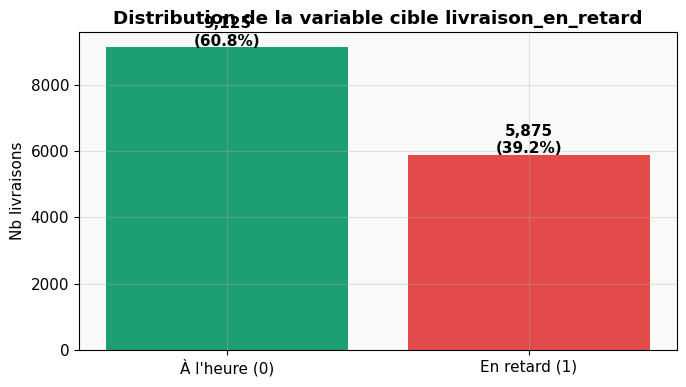

✅ Sauvegardé : ./outputs/logitrack_target_distribution.png


In [17]:
fig, ax = plt.subplots(figsize=(7, 4))
counts = df_liv['livraison_en_retard'].value_counts()
bars = ax.bar(['À l\'heure (0)', 'En retard (1)'], counts.values,
              color=[COLORS['secondary'], COLORS['danger']])
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'{val:,}\n({val/len(df_liv)*100:.1f}%)',
            ha='center', fontweight='bold')
ax.set_title('Distribution de la variable cible livraison_en_retard', fontweight='bold')
ax.set_ylabel('Nb livraisons')
plt.tight_layout()
plt.savefig(f'{SAVE_PATH}logitrack_target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ Sauvegardé : {SAVE_PATH}logitrack_target_distribution.png')

> **INTERPRÉTATION :**
> - **~39%** de livraisons en retard — dataset quasi-équilibré, favorable pour le ML
> - Pas besoin de SMOTE ni de `class_weight` agressif
>
> **MÉTIER :** Un taux de 39% est alarmant — presque 2 livraisons sur 5 sont en situation de risque. Le modèle ML du NB5 devra distinguer ces cas dès l'expédition pour permettre une intervention préventive.

---
## Étape 5 — Sélection des features et export

### MÉTHODE — Pourquoi sélectionner les colonnes ?
On exporte uniquement les colonnes nécessaires pour le ML et le dashboard. Les colonnes sources redondantes (`date_livraison_reelle`, `risque_douanier` texte, `mode_transport` texte) sont exclues :
- **Leakage :** `date_livraison_reelle` contient implicitement le résultat de la livraison
- **Redondance :** `risque_douanier_num` remplace `risque_douanier` pour le ML
- **Poids :** un DataFrame allégé est plus rapide à charger en NB3, NB5 et Power BI

In [18]:
COLS_ANALYTICS = [
    # Identifiants
    'livraison_id', 'client_id', 'transporteur_id',
    'entrepot_origine_id', 'entrepot_dest_id', 'route_id',
    # Géographie
    'pays_origine', 'pays_destination',
    # Dates et temporel
    'date_creation', 'date_enlevement', 'date_livraison_prevue',
    'annee', 'mois', 'jour_semaine', 'est_weekend',
    'est_fin_mois', 'heure_enlevement', 'delai_prep_heures',
    'mois_sin', 'mois_cos',
    # Logistique
    'type_colis', 'poids_kg', 'volume_m3', 'densite_kg_m3',
    'priorite', 'priorite_num',
    'sla_jours_contractuel', 'duree_reelle_jours',
    'distance_km', 'duree_standard_jours', 'nb_points_controle',
    'ratio_duree_vs_standard', 'delai_relatif_sla',
    # Performance historique
    'taux_breach_transporteur', 'taux_breach_corridor',
    'taux_breach_entrepot_origine', 'taux_livraison_temps',
    'ponctualite_entrepot_origine',
    # Référentiels encodés
    'risque_douanier', 'risque_douanier_num',
    'mode_transport', 'mode_transport_num',
    'segment', 'segment_num',
    'penalite_retard_pct', 'transporteur_actif',
    # Résultats
    'statut', 'sla_breach', 'escalade', 'in_backlog', 'incident',
    'delai_jours', 'csat', 'cout_transport_fcfa', 'penalite_fcfa',
    # Variable cible ML
    'livraison_en_retard',
]

df_analytics = df_liv[COLS_ANALYTICS].copy()
df_analytics.to_csv(f'{SAVE_PATH}logitrack_analytics.csv', index=False)

print(f'✅ logitrack_analytics.csv exporté')
print(f'   Dimensions     : {df_analytics.shape}')
print(f'   Nulls restants : {df_analytics.isnull().sum().sum()}')
print(f'   Localisation   : {SAVE_PATH}')
print(f'\nAperçu des 5 premières colonnes :')
print(df_analytics.head(3).to_string())

✅ logitrack_analytics.csv exporté
   Dimensions     : (15000, 56)
   Nulls restants : 17731
   Localisation   : ./outputs/

Aperçu des 5 premières colonnes :
  livraison_id client_id transporteur_id entrepot_origine_id entrepot_dest_id route_id   pays_origine pays_destination date_creation date_enlevement date_livraison_prevue  annee  mois  jour_semaine  est_weekend  est_fin_mois  heure_enlevement  delai_prep_heures  mois_sin  mois_cos      type_colis  poids_kg  volume_m3  densite_kg_m3  priorite  priorite_num  sla_jours_contractuel  duree_reelle_jours  distance_km  duree_standard_jours  nb_points_controle  ratio_duree_vs_standard  delai_relatif_sla  taux_breach_transporteur  taux_breach_corridor  taux_breach_entrepot_origine  taux_livraison_temps  ponctualite_entrepot_origine risque_douanier  risque_douanier_num mode_transport  mode_transport_num         segment  segment_num  penalite_retard_pct  transporteur_actif             statut  sla_breach  escalade  in_backlog        incident  

---
## Bilan du Notebook 2

### Corrections appliquées

| Action | Nb | Méthode |
|---|---|---|
| Poids aberrants corrigés | **2** | Médiane par type_colis |
| CSAT hors plage → NULL | **2** | Valeur inconnue > valeur fausse |
| Délais aberrants recalculés | **4** | `duree_reelle - sla_contractuel` |
| Transporteur suspendu marqué | **1** | Colonne `transporteur_actif` |

### Features créées

| Feature | Type | Rôle ML |
|---|---|---|
| `mois_sin` / `mois_cos` | Float | Saisonnalité cyclique |
| `est_fin_mois` | Binaire | Pic de fin de période |
| `delai_prep_heures` | Float | Efficacité logistique à l'origine |
| `taux_breach_transporteur` | Float | Performance historique partenaire |
| `taux_breach_corridor` | Float | Fiabilité de la route |
| `taux_breach_entrepot_origine` | Float | Goulot d'étranglement entrepôt |
| `delai_relatif_sla` | Float | Position vs SLA (>1 = en retard) |
| `ratio_duree_vs_standard` | Float | Écart durée réelle vs théorique |
| `risque_douanier_num` | Ordinal | 0=Faible, 1=Moyen, 2=Élevé |
| `priorite_num` | Ordinal | 0=Standard, 1=Express, 2=Urgent |
| `ponctualite_entrepot_origine` | Float | Fiabilité du hub de départ |

**Fichier exporté :** `logitrack_analytics.csv` — disponible dans `SAVE_PATH`

**Pour le NB3 :** charger `logitrack_analytics.csv` avec DuckDB pour les analyses SQL avancées — corridors, transporteurs, LAG mensuel, heatmap volume.

---

**DataProjectLab** — apprendre la data sur des cas concrets, structurés et orientés métier.